# Initialization 

These are the models we've chosen for the demonstration: 
- voyage-large-2, VoyageAI
- text-embedding-3-large, OpenAI
- BioGPT, Microsoft (to make sure we have something to cover the biomedical domain specifically)

In [1]:
import os
import yaml
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

from tqdm.auto import tqdm

In [2]:
OPEN_AI_KEY = os.getenv('OPEN_AI_KEY')
VOYAGE_AI_KEY = os.getenv('VOYAGE_AI_KEY')

## Voyage
https://docs.voyageai.com/docs/embeddings

In [3]:
import voyageai

vo = voyageai.Client(api_key=VOYAGE_AI_KEY)

def get_voyageai(texts):
    embeddings = vo.embed(texts, model="voyage-large-2", input_type="document").embeddings
    return embeddings

In [4]:
# from transformers import AutoTokenizer

# voyage_tokenizer = AutoTokenizer.from_pretrained('voyageai/voyage-3')

## Marqo
https://docs.marqo.ai/latest/quickstart/marqo/starter-guides/text-search/

## OpenAI

https://platform.openai.com/docs/guides/embeddings#embedding-models

In [5]:
from openai import OpenAI

client = OpenAI(api_key=OPEN_AI_KEY)

def get_openai(texts):
    response = client.embeddings.create(input=texts, model="text-embedding-3-large")
    return [item.embedding for item in response.data]

In [6]:
import tiktoken

openai_tokenizer = tiktoken.encoding_for_model("text-embedding-3-large")

## BioGPT

In [7]:
# todo figure this out 

# from typing import Union

# import torch
# from sentence_transformers import SentenceTransformer, util
# from transformers import AutoModel, AutoTokenizer


# class BioGPT:
#     """https://huggingface.co/microsoft/biogpt"""

#     tokenizer = AutoTokenizer.from_pretrained("microsoft/biogpt")
#     model = AutoModel.from_pretrained("microsoft/biogpt")

#     def __init__(self, max_input_len: int = 512) -> None:
#         self.max_length = max_input_len

#     def mean_pooling(self, model_output: torch.tensor, attention_mask: torch.tensor) -> torch.tensor:
#         token_embeddings = model_output["last_hidden_state"]
#         input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
#         sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
#         sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
#         return sum_embeddings / sum_mask

#     def max_pooling(self, model_output: torch.tensor, attention_mask: torch.tensor) -> torch.tensor:
#         token_embeddings = model_output["last_hidden_state"]
#         input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
#         return torch.max(
#             token_embeddings * input_mask_expanded + (1.0 - input_mask_expanded) * (-1e9), 1
#         ).values  # noqa: PD011

#     def last_token_embedding(self, model_output: torch.tensor, attention_mask: torch.tensor) -> torch.tensor:
#         token_embeddings = model_output["last_hidden_state"]
#         last_token_indexes = torch.sum(attention_mask, dim=1) - 1
#         return token_embeddings[range(token_embeddings.shape[0]), last_token_indexes]

#     def encode(self, sentences: Union[str, list[str]], pooling: str = "last") -> np.ndarray | None:
#         encoded_input = self.tokenizer(
#             sentences, padding=True, truncation=True, max_length=self.max_length, return_tensors="pt"
#         )

#         with torch.no_grad():
#             model_output = self.model(**encoded_input)

#         if pooling == "mean":
#             return self.mean_pooling(model_output, encoded_input["attention_mask"])  # [0].numpy()
#         if pooling == "max":
#             return self.max_pooling(model_output, encoded_input["attention_mask"])  # [0].numpy()
#         if pooling == "last":
#             return self.last_token_embedding(model_output, encoded_input["attention_mask"])  # [0].numpy()
#         return None


# def get_model(model_name: str) -> Union[SentenceTransformer, BioGPT] | None:
#     if model_name in [
#         "sentence-transformers/multi-qa-mpnet-base-dot-v1",
#         "thenlper/gte-base",
#         "BAAI/bge-base-en-v1.5",
#         "intfloat/e5-base-v2",
#     ]:
#         return SentenceTransformer(model_name)
#     if model_name == "biogpt":
#         return BioGPT()
#     return None

In [8]:
methods = [
    ("openai", get_openai, 1000),
    ("voyage", get_voyageai, 100)
]

In [9]:
# todo look at that 

def get_embeddings(texts, model, batch_size=100):
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing batches"):
        batch_texts = texts[i:i + batch_size]
        embeddings += model(batch_texts)
    
    return embeddings

# Queries embeddings

In [10]:
queries_pairs = [
    ("Сonnection between LDH markers and persistent exhaustion", "How are lactate dehydrogenase levels and chronic fatigue related?"),
    ("What published data is available for impact on daily activities with anti-C5 therapy?", "Is there evidence on how C5i impacts patients' ability to perform daily tasks?"),
    ("Is fingolimod a comparable alternative to dimethyl fumarate in multiple sclerosis management?", "Can Gilenya be used as a replacement for Tecfidera in treating multiple sclerosis?"),
    ("Addressing IVN in the treatment approach for PNH.", "Intravascular hemolysis as a factor in managing paroxysmal nocturnal hemoglobinuria."),
    ("Do high D dimer levels influence the risk of developing blood clots?", "What is the relationship between elevated D-dimer levels and thrombosis risk?"),
    ("How long have you been ill?", "Since when have you been experiencing these symptoms?"),
    ("Optical coherence tomography applications in diagnosing retinal diseases.", "What is the use of OCT in clinical assessments for retinal disorders?"),
    ("Symptoms of anemia?", "How does anemia manifest?"),
    ("The advantages of maintaining a fitness routine.", "What are the health benefits of regular physical activity")
]

In [11]:
queries_df = pd.DataFrame(queries_pairs, columns=["question 1", "question 2"])
queries_df.head()

,question 1,question 2
0,Сonnection between LDH markers and persistent ...,How are lactate dehydrogenase levels and chron...
1,What published data is available for impact on...,Is there evidence on how C5i impacts patients'...
2,Is fingolimod a comparable alternative to dime...,Can Gilenya be used as a replacement for Tecfi...
3,Addressing IVN in the treatment approach for PNH.,Intravascular hemolysis as a factor in managin...
4,Do high D dimer levels influence the risk of d...,What is the relationship between elevated D-di...


Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

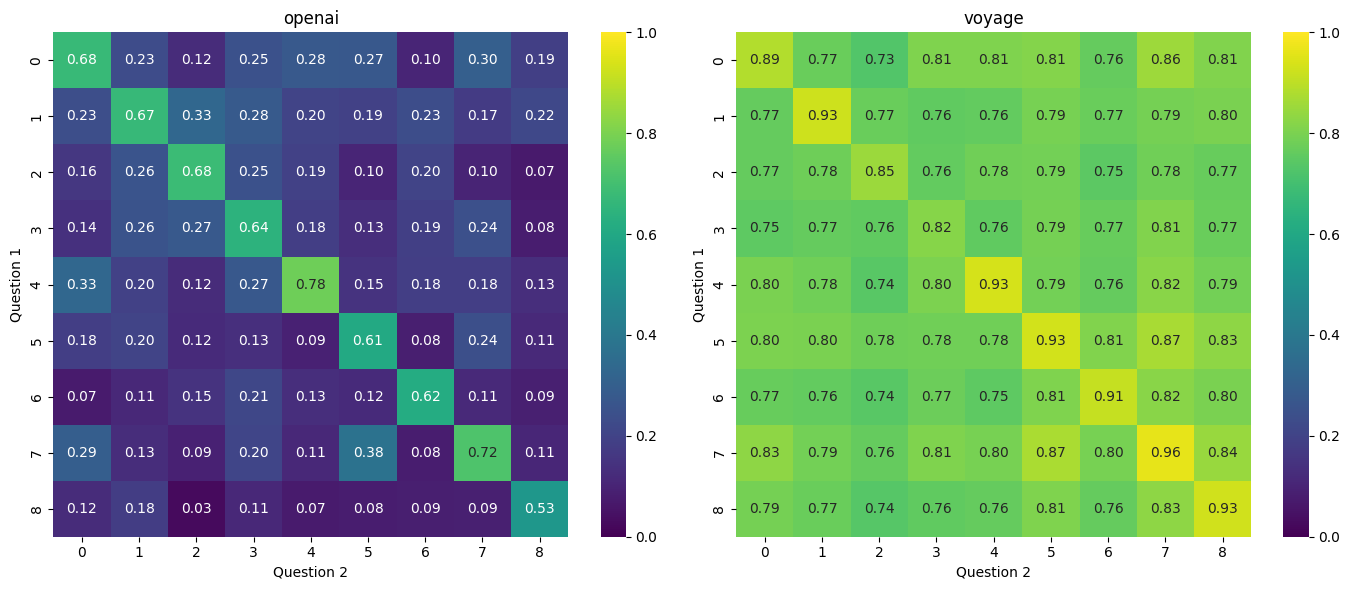

In [12]:
plt.figure(figsize=(14, 6))

for i, (title, method) in enumerate(methods, start=1):
    # todo shouldn't it be symmetrical?

    embeddings_q1 = get_embeddings(queries_df["question 1"].tolist(), method)
    embeddings_q2 = get_embeddings(queries_df["question 2"].tolist(), method)

    similarity_matrix = cosine_similarity(embeddings_q1, embeddings_q2)
    
    plt.subplot(1, 2, i)
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='viridis', cbar=True, vmin=0, vmax=1)
    plt.title(title)
    
    plt.xlabel('Question 2')
    plt.ylabel('Question 1')
    
plt.tight_layout()
plt.show()

# Documents embeddings

For the demo we've downloaded from [PubMed](https://pubmed.ncbi.nlm.nih.gov/) all papers for these [MeSH terms](https://meshb.nlm.nih.gov/treeView) for last 5 years:

- Diabetes, Gestational [C19.246.200] (6423 abstracts)
- Latent Autoimmune Diabetes in Adults [C19.246.656] (109 abstracts)
- Prediabetic State [C19.246.774] (3120 abstracts)

We downloaded 3 sets of papers, so let's try to divide them into 3 clusters

todo: check quantitites

In [13]:
import umap

from bokeh.layouts import row 
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.plotting import figure, output_notebook, show

from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [14]:
documents_df = pd.read_csv('data/diabetes.csv')

In [15]:
# todo should this be balanced?

category_counts = documents_df['category'].value_counts()
category_counts

category
gestational    6423
prediabetes    3120
lada            109
Name: count, dtype: int64

In [16]:
documents_df['voyage'] = get_embeddings(documents_df['text'].tolist(), get_voyageai)

Processing batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [17]:
documents_df['openai'] = get_embeddings(documents_df['text'].tolist(), get_openai, 1000)

Processing batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [18]:
n_categories = 3

category_colors = {'gestational': '#1f77b4', 
                   'prediabetes': '#ff7f0e', 
                   'lada': '#2ca02c'}

documents_df['color'] = documents_df['category'].map(category_colors)
documents_df['label'] = documents_df['category'] + ' ' + documents_df['pmid'].astype(str) + ': ' + documents_df['title']

Completely redundant data viz (just a sanity check) 

In [19]:
output_notebook()

def create_umap_plot(df, embedding_column):
    
    data = np.array(df[embedding_column].tolist())
    
    # reducer = umap.UMAP(n_neighbors=10, min_dist=0.05)  # todo what are the default params? 
    reducer = umap.UMAP()  # todo what are the default params? 

    projection = reducer.fit_transform(data)
    
    source = ColumnDataSource(data={
        'x': projection[:, 0],
        'y': projection[:, 1],
        'colors': df['color'],
        'labels': df['label']
    })
    
    plot = figure(title=f"'UMAP projection of {embedding_column} embeddings'", 
                  width=500, height=400, tools="pan,wheel_zoom,box_zoom,reset")
    plot.add_tools(HoverTool(tooltips=[("", "@labels")]))
    plot.scatter('x', 'y', color='colors', source=source, size=4, alpha=0.7)

    return plot

Loading BokehJS ...

In [20]:
plot1 = create_umap_plot(documents_df, 'voyage')
plot2 = create_umap_plot(documents_df, 'openai')

show(row(plot1, plot2))

In [21]:
columns = ['voyage', 'openai']
results = []

umap_reducer = umap.UMAP(n_components=5, random_state=42)

for column in columns:
    reduced = umap_reducer.fit_transform(documents_df[column].tolist())
    
    clustering = SpectralClustering(n_clusters=n_categories, random_state=42, affinity='nearest_neighbors', n_neighbors=10)  # todo defaults?
    clusters = clustering.fit_predict(reduced)
    
    documents_df[f'{column}_cluster'] = clusters
    labels_true = documents_df['category']
    labels_pred = documents_df[f'{column}_cluster']
    
    ari_score = adjusted_rand_score(labels_true, labels_pred)
    silhouette = silhouette_score(np.vstack(reduced), labels_pred)
    
    results.append([column, round(ari_score, 2), round(silhouette, 2)])

/Users/mariachakchurina/projects/bioage/experiments/venv/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/mariachakchurina/projects/bioage/experiments/venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/mariachakchurina/projects/bioage/experiments/venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [22]:
pd.DataFrame(results, columns=['Column', 'ARI', 'Silhouette'])

,Column,ARI,Silhouette
0,voyage,-0.01,0.32
1,openai,-0.00,-0.20


# How documents and queries work together

In [23]:
gestational_df = documents_df[documents_df['category'] == 'gestational']

In [24]:
from matplotlib.ticker import FormatStrFormatter

def plot_distances_distribution(df, category_descriptions):
    fig, axes = plt.subplots(len(methods), 2, figsize=(8, len(methods) * 2.5), sharey=True)

    for i, (model, method) in enumerate(methods):
        for j, category_description in enumerate(category_descriptions):
            category_embedding = get_embeddings([category_description], method)
            similarities = cosine_similarity(df[model].tolist(), category_embedding).flatten()

            sns.histplot(similarities, bins=20, kde=True, alpha=0.7, ax=axes[i, j])
            axes[i, j].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            axes[i, j].set_title(f'"{model}:" {category_description}')
            axes[i, j].text(
                0.25, 0.92, 
                f'Min: {np.min(similarities):.2f}\n'
                f'Max: {np.max(similarities):.2f}\n'
                f'Mean: {np.mean(similarities):.2f}',
                transform=axes[i, j].transAxes,
                fontsize=9, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.5)
            )

    plt.tight_layout()
    plt.show()

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

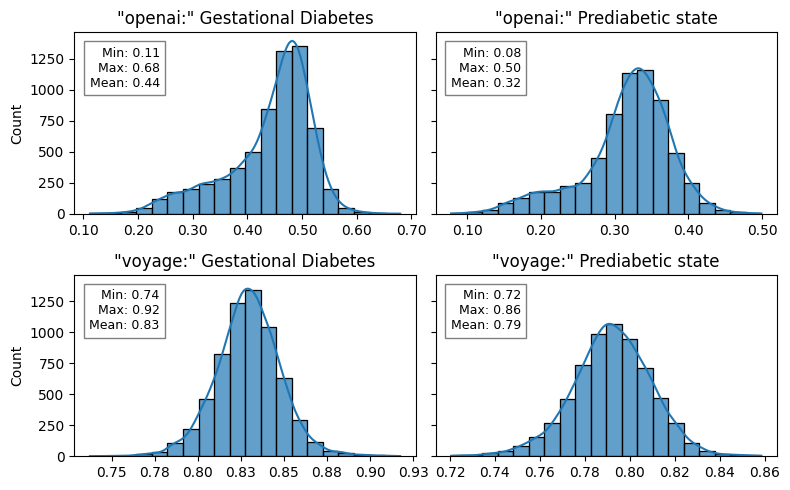

In [25]:
plot_distances_distribution(gestational_df, ["Gestational Diabetes", "Prediabetic state"])

# Tolerance to spelling errors 

## Typos

You can take typos from logs, create them manually or generate ([typo](https://pypi.org/project/typo/)). Anyway, make sure that typos of varoius types are represented.

In [26]:
typos = {
    'biomarkers': 'nbiomarkers',  # лишняя в начале
    'transfusions': 'transfusilons',  # лишняя в середине 
    'ravulizumab': 'ravulizumanb',  # лишняя в конце 
    'clinical trial': 'xlinical trial',  # ошибка в начале
    'meningococcal vaccine': 'meningococcql vacine',  # ошибка в середине
    'thrombosis': 'thrombosie',  # ошибка в конце
    'ozempik': '0zempik',  # похожий символ в начале
    'diagnosis': 'diaqnosis',  # похожий символ в середине 
    'fatigue': 'fatiguc', # похожий символ в конце 
    'patient': 'ptaient',  # char swap в начале
    'myasthenia': 'mysathenia',  # char swap в середине
    'therapy': 'therpay',  # char swap в конце
    'pregnancy': 'regnancy',  # пропуск в начале 
    'symptoms': 'symptos',  # пропуск в середине 
    'epidemiology': 'epidemiolog'  # пропуск в конце 
}

In [27]:
typos_df = pd.DataFrame(list(typos.items()), columns=["word", "typo"])
typos_df.head()

,word,typo
0,biomarkers,nbiomarkers
1,transfusions,transfusilons
2,ravulizumab,ravulizumanb
3,clinical trial,xlinical trial
4,meningococcal vaccine,meningococcql vacine


Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

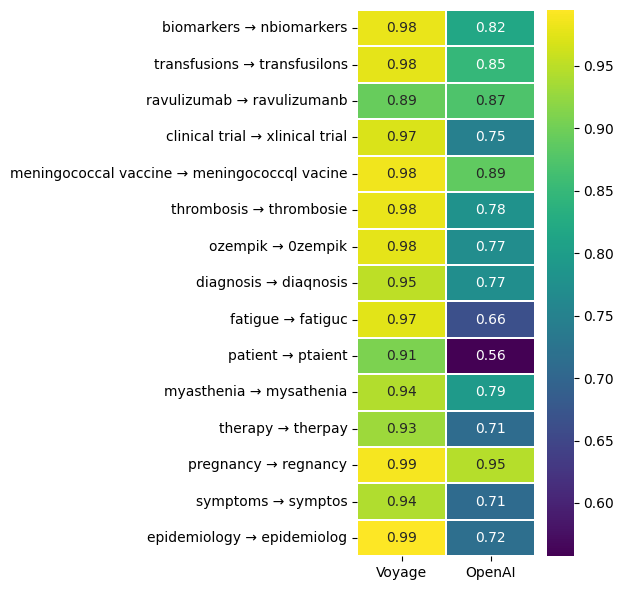

In [28]:
for model, method, _ in methods:
    embeddings_original = get_embeddings(typos_df["word"].tolist(), method)
    embeddings_typos = get_embeddings(typos_df["typo"].tolist(), method)
    similarity_scores = np.diag(cosine_similarity(embeddings_original, embeddings_typos))
    
    typos_df[model] = similarity_scores

yticklabels = [f"{row['word']} → {row['typo']}" for _, row in typos_df.iterrows()]
scores_matrix = typos_df[["voyage", "openai"]].values

fig, ax = plt.subplots(figsize=(6, len(typos_df) * 0.4))
sns.heatmap(scores_matrix, annot=True, fmt=".2f", yticklabels=yticklabels, 
            xticklabels=["Voyage", "OpenAI"], cmap='viridis', linewidths=.25, ax=ax)

plt.tight_layout()
plt.show()

## Tokenization

In [29]:
for term in typos:
    encoded_term = tokenizer.encode(term)
    decoded_tokens = [tokenizer.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_term]
        
    encoded_typo = tokenizer.encode(typos[term])
    decoded_typo_tokens = [tokenizer.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_typo]

    print(f"{term}: {'-'.join(decoded_tokens)} / {'-'.join(decoded_typo_tokens)}")

NameError: name 'tokenizer' is not defined

In [30]:
tokenizers = {
    "openai": openai_tokenizer,
    # "voyageai": voyage_tokenizer
}

results = {}
for tokenizer, tokenizer_func in tokenizers.items():
    tokenizer_results = []
    for term in typos:
        encoded_term = tokenizer_func.encode(term)
        decoded_tokens = [tokenizer_func.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_term]
        
        encoded_typo = tokenizer_func.encode(typos[term])
        decoded_typo_tokens = [tokenizer_func.decode_single_token_bytes(token).decode('utf-8', errors='replace').strip() for token in encoded_typo]
        
        tokenizer_results.append(f"{'-'.join(decoded_tokens)} / {'-'.join(decoded_typo_tokens)}")
    results[tokenizer] = tokenizer_results


pd.DataFrame(results, index=typos.keys()).head(20)

,openai
biomarkers,bi-om-arkers / n-bi-om-arkers
transfusions,trans-f-usions / trans-f-us-il-ons
ravulizumab,r-av-ul-iz-um-ab / r-av-ul-iz-uman-b
clinical trial,clinical-trial / x-lin-ical-trial
meningococcal vaccine,men-ing-oc-oc-cal-vaccine / men-ing-oc-occ-ql-...
thrombosis,th-rom-b-osis / th-rom-bos-ie
ozempik,oz-emp-ik / 0-z-emp-ik
diagnosis,di-agnosis / dia-qn-osis
fatigue,fat-igue / fat-ig-uc
patient,patient / pta-ient


# Domain terms

In [31]:
import nltk
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('wordnet')

from nltk.corpus import wordnet

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mariachakchurina/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [32]:
words = list(wordnet.words())
len(words)

147306

In [33]:
terms = [
    "Selective serotonin reuptake inhibitor",  # Class of antidepressants
    "BBB disruption therapy",  # Method of temporarily disrupting the blood-brain barrier to deliver drugs to brain tissue
    "CAR T-cell therapy",  # Immunotherapy where modified T-cells attack cancer cells
    "Meningococcal vaccine",  # Vaccine against infections causing meningitis
    "Zolgensma",  # Gene therapy for spinal muscular atrophy
    "ReoPro",  # Drug preventing blood clotting during vascular surgeries
    "Rickettsia prowazekii",  # Bacterium causing epidemic typhus
    "Neurofilament light chain",  # Biomarker for diagnosing neurological disorders
    "lncRNA",  # Long non-coding RNAs with gene regulatory functions
    "Antisense oligonucleotide",  # Short synthetic DNA or RNA for therapy of genetic diseases and cancer
    "Gamma Knife procedure",  # Neurological radiosurgery for treating brain tumors
    "Cladribine",  # Drug for treating multiple sclerosis
    "PD-L1 mAbs",  # Monoclonal antibodies helping the immune system recognize and destroy cancer cells
    "Kabuki syndrome"  # Rare genetic disorder
]

In [34]:
terms_df = pd.DataFrame(terms, columns=["term"])
terms_df.head()

,term
0,Selective serotonin reuptake inhibitor
1,BBB disruption therapy
2,CAR T-cell therapy
3,Meningococcal vaccine
4,Zolgensma


In [36]:
for model, method, batch_size in methods:
    terms_embeddings = get_embeddings(terms_df["term"].tolist(), method)
    wordnet_embeddings = get_embeddings(words, method, batch_size)
    similarities = cosine_similarity(terms_embeddings, wordnet_embeddings)
    
    results = []
    for term, term_similarities in zip(terms, similarities):
        top_indices = np.argsort(term_similarities)[-3:][::-1]
        top_words = [words[i] for i in top_indices]
        results.append(", ".join(top_words))
    
    terms_df[model] = results

terms_df.head(20)

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1474 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batches:   0%|          | 0/1474 [00:00<?, ?it/s]

,term,openai,voyage
0,Selective serotonin reuptake inhibitor,"selective-serotonin_reuptake_inhibitor, ssri, ...","selective-serotonin_reuptake_inhibitor, sertra..."
1,BBB disruption therapy,"blood-brain_barrier, thrombolytic_therapy, clo...","therapeutic, therapy, therapeutical"
2,CAR T-cell therapy,"immunotherapy, killer_t_cell, immunotherapeutic","immunotherapy, immunotherapeutic, therapeutics"
3,Meningococcal vaccine,"meningitis, pneumococcal_vaccine, epidemic_men...","pneumococcal_vaccine, meningitis, vaccine"
4,Zolgensma,"zoloft, lofortyx, vincristine","zetland, zinzendorf, nijmegen"
5,ReoPro,"lipo-hepin, thrombolytic_agent, plavix","pro, re, ream"
6,Rickettsia prowazekii,"rickettsia, rickettsiaceae, rickettsiales","rickettsia, rickettsial, rickettsiales"
7,Neurofilament light chain,"neurolysin, nerve_growth_factor, neuropil","neurofibromatosis, nucleoprotein, fibrinopeptide"
8,lncRNA,"nrna, nuclear_rna, informational_rna","nuclear_rna, mrna, rna"
9,Antisense oligonucleotide,"nucleoside, antimetabolite, dideoxyinosine","antibody, recombinant, isoantibody"
